In [1]:
import os
import glob
import shutil
import zipfile
import math
import sys
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.amp import autocast, GradScaler
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torch.optim.lr_scheduler import LambdaLR

In [2]:
# Copy the project from Google Drive to Colab SSD
!cp -r "/content/drive/MyDrive/COLAB/PROJECTs/LatentDiffusion-FaceGen/LatentDiffusion-FaceGen-main" /content/

In [3]:
project_root = "/content/LatentDiffusion-FaceGen-main"
sys.path.append(project_root)
sys.path.append(f"{project_root}/diffusion")
sys.path.append(f"{project_root}/vae")

In [5]:
# Configuration
from config import cfg

# Diffusion model and building blocks
from diffusion.model_diff import AdvancedUNet2d_diff, ResidualBlock_diff, SelfAttention2D, BottleneckBlock

# Time embedding and timestep strategy
from diffusion.time import TimeEmbedding, SinusoidalPosEmb, t_strategy_v3

# Exponential moving average (EMA) tracking
from diffusion.ema import EMA

# Diffusion scheduler, sampling, and loss functions
from diffusion.scheduler import DiffusionScheduler

# Visualization
from diffusion.visualize import (
    visualize_unet2d_output,
    generate_and_visualize_ddim_sample
)

# Early stopping
from vae.earlyStopping import EarlyStopping

# VAE model
from vae.model_vae import VAE


In [6]:
# 1. Copy pretrained VAE weights from Google Drive to local SSD
drive_path = "/content/drive/MyDrive/COLAB/PROJECTs/LatentDiffusion-FaceGen/LatentDiffusion-FaceGen-main/checkpoints/best_vae_model.pth"
ssd_path   = "/content/best_vae_model.pth"
shutil.copy(drive_path, ssd_path)

# 2. Re-initialize VAE and move to device

vae = VAE(in_channels=cfg.in_channels, latent_channels=cfg.latent_channels, out_channels=cfg.out_channels)
vae.to(cfg.device)

# 3. Load pretrained weights
vae.load_state_dict(torch.load(ssd_path, map_location=cfg.device))
vae.eval()

VAE(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): ResidualBlock(
        (norm1): GroupNorm(3, 3, eps=1e-05, affine=True)
        (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm2): GroupNorm(8, 8, eps=1e-05, affine=True)
        (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (residual_layer): Conv2d(3, 8, kernel_size=(1, 1), stride=(1, 1))
        (activation): SiLU()
      )
      (1): Downsample(
        (main): Sequential(
          (0): Conv2d(8, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): SiLU()
        )
        (skip): Conv2d(8, 64, kernel_size=(1, 1), stride=(2, 2))
      )
      (2): ResidualBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
        (conv2):

In [7]:
# Extract FFHQ dataset from Google Drive ZIP if not already extracted
drive_zip_path = "/content/drive/MyDrive/COLAB/DATASETs/FFHQ/flickrfaceshq-dataset-ffhq.zip"
extract_dir = "./ffhq_dataset"

In [8]:
# Extract dataset from ZIP file if not already extracted
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(drive_zip_path, 'r') as zip_ref:
        file_list = zip_ref.namelist()
        print(f"{len(file_list)} files are being extracted...")
        for file in tqdm(file_list):
            zip_ref.extract(member=file, path=extract_dir)


52001 files are being extracted...


100%|██████████| 52001/52001 [03:08<00:00, 275.88it/s]


In [8]:
# Image preprocessing: resize, to tensor, normalize
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.42, 0.44, 0.41], std=[0.42, 0.43, 0.40])
])

In [9]:
# Custom dataset for loading FFHQ images
class FFHQDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.file_paths = glob.glob(f"{root_dir}/*.png") + glob.glob(f"{root_dir}/*.jpg")
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

# Create dataset instance with preprocessing
dataset = FFHQDataset(root_dir=extract_dir, transform=transform)

In [10]:
# Limit dataset to a subset of total images
limited_dataset, _ = random_split(dataset, [cfg.subset_size, len(dataset) - cfg.subset_size])

# Train-test split from the limited subset
train_size = int(0.8 * cfg.subset_size)
test_size = cfg.subset_size - train_size
train_dataset, test_dataset = random_split(limited_dataset, [train_size, test_size])

# DataLoader for training and testing
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)


In [11]:
# Clear GPU memory state
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [12]:
# Define diffusion scheduler, model, optimizer, EMA, AMP, and early stopping

scheduler = DiffusionScheduler(
    num_timesteps=cfg.num_timesteps, beta_start=1e-4, beta_end=0.02, device=cfg.device
)

diffusion_model = AdvancedUNet2d_diff(
    latent_channels=cfg.latent_channels,
    time_emb_dim=cfg.time_dim
).to(cfg.device)

optimizer = torch.optim.Adam(
    diffusion_model.parameters(),
    lr=cfg.optimizer_lr, betas=(0.9, 0.999), weight_decay=0
)

ema_helper = EMA(diffusion_model, decay=0.999)
scaler = GradScaler()

early_stopper = EarlyStopping(
    patience=cfg.early_stopping_patience,
    min_delta=1e-4,
    checkpoint_path="/content/drive/MyDrive/COLAB/Checkpoints/ldm/best_diff_model.pth"
)


In [13]:
# 2. Step-based warmup + cosine decay learning rate schedule

steps_per_epoch = len(train_loader)
total_steps     = cfg.epoch_diff * steps_per_epoch
warmup_steps    = int(0.1 * total_steps)  # Warmup for first 10% of total steps

# Cosine decay after warmup
def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

lr_scheduler = LambdaLR(optimizer, lr_lambda)

# 3. Number of warmup epochs before applying weighted loss
warmup_epochs = cfg.warmup_epochs  # Use uniform MSE loss for first few epochs

# 4. Statistics & gradient tracking hooks for debugging
stats, grads = {}, {}

# Track output std from each target module during forward pass
def make_stats_hook(name):
    def hook(module, inp, out):
        stats.setdefault(name, []).append(out.std().item())
    return hook

# Track gradient norm from each target module during backward pass
def make_grads_hook(name):
    def hook(module, grad_in, grad_out):
        grads.setdefault(name, []).append(grad_out[0].norm().item())
    return hook

# Register hooks for ResidualBlock_diff and SelfAttention2D layers
for name, module in diffusion_model.named_modules():
    if isinstance(module, ResidualBlock_diff) or isinstance(module, SelfAttention2D):
        module.register_forward_hook(make_stats_hook(name))
        module.register_full_backward_hook(make_grads_hook(name))


Epoch 1/10:   0%|          | 0/8000 [00:00<?, ?it/s]

[Epoch 0 - Batch 0] latent mean: -0.0015614575240761042
[Epoch 0 - Batch 0] latent std: 0.1147693395614624


Epoch 1/10:   0%|          | 1/8000 [00:00<1:36:26,  1.38it/s, loss=1.3290, lr=1.00e-07]

[Epoch 0 - Batch 0] decoder output min: -0.9859916567802429
[Epoch 0 - Batch 0] decoder output max: 1.0
[Epoch 0 - Batch 0] decoder output std: 0.6010333895683289
[Epoch 0 - Batch 0] x_noisy mean: -0.0010125783737748861
[Epoch 0 - Batch 0] x_noisy std: 0.14628683030605316


Epoch 1/10:   6%|▋         | 502/8000 [02:19<30:03,  4.16it/s, loss=0.6740, lr=2.51e-05]

...

[Epoch 0 - Batch 7000] decoder output min: -0.9976446032524109
[Epoch 0 - Batch 7000] decoder output max: 1.0
[Epoch 0 - Batch 7000] decoder output std: 0.575554609298706
[Epoch 0 - Batch 7000] x_noisy mean: -0.0012797649251297116
[Epoch 0 - Batch 7000] x_noisy std: 0.14858478307724


Epoch 1/10:  94%|█████████▍| 7502/8000 [25:04<01:58,  4.19it/s, loss=0.5971, lr=1.95e-04]

[Epoch 0 - Batch 7500] decoder output min: -0.9920420050621033
[Epoch 0 - Batch 7500] decoder output max: 1.0
[Epoch 0 - Batch 7500] decoder output std: 0.6250739693641663
[Epoch 0 - Batch 7500] x_noisy mean: -0.0014519295655190945
[Epoch 0 - Batch 7500] x_noisy std: 0.14426368474960327


Epoch 1/10: 100%|██████████| 8000/8000 [26:41<00:00,  5.00it/s, loss=0.5594, lr=1.94e-04]



Epoch 1 done. Avg loss: 0.626179
t samples: [22, 13, 28, 29, 26] ... [26, 23, 29, 27, 14] 

—— Katman İstatistikleri ——
dres1                     — std: 0.9279 ← 0.9291
down1.resblock1           — std: 0.8491 ← 0.8501
down1.resblock2           — std: 0.8370 ← 0.8370
dres2                     — std: 0.8837 ← 0.8838
attn2                     — std: 1.0019 ← 1.0017
down2.resblock1           — std: 0.9089 ← 0.9113
down2.resblock2           — std: 0.9550 ← 0.9560
dres3                     — std: 0.9713 ← 0.9721
attn3                     — std: 1.0154 ← 1.0157
down3.resblock1           — std: 0.9160 ← 0.9174
down3.resblock2           — std: 0.9574 ← 0.9587
bottleneck.block1         — std: 0.9798 ← 0.9808
bottleneck.attn           — std: 0.9986 ← 0.9982
ures1                     — std: 0.5442 ← 0.5402
up1.resblock1             — std: 0.6593 ← 0.6624
up1.resblock2             — std: 0.8508 ← 0.8553
ures2                     — std: 0.8933 ← 0.8967
attn2d                    — std: 1.0046 ← 1.00

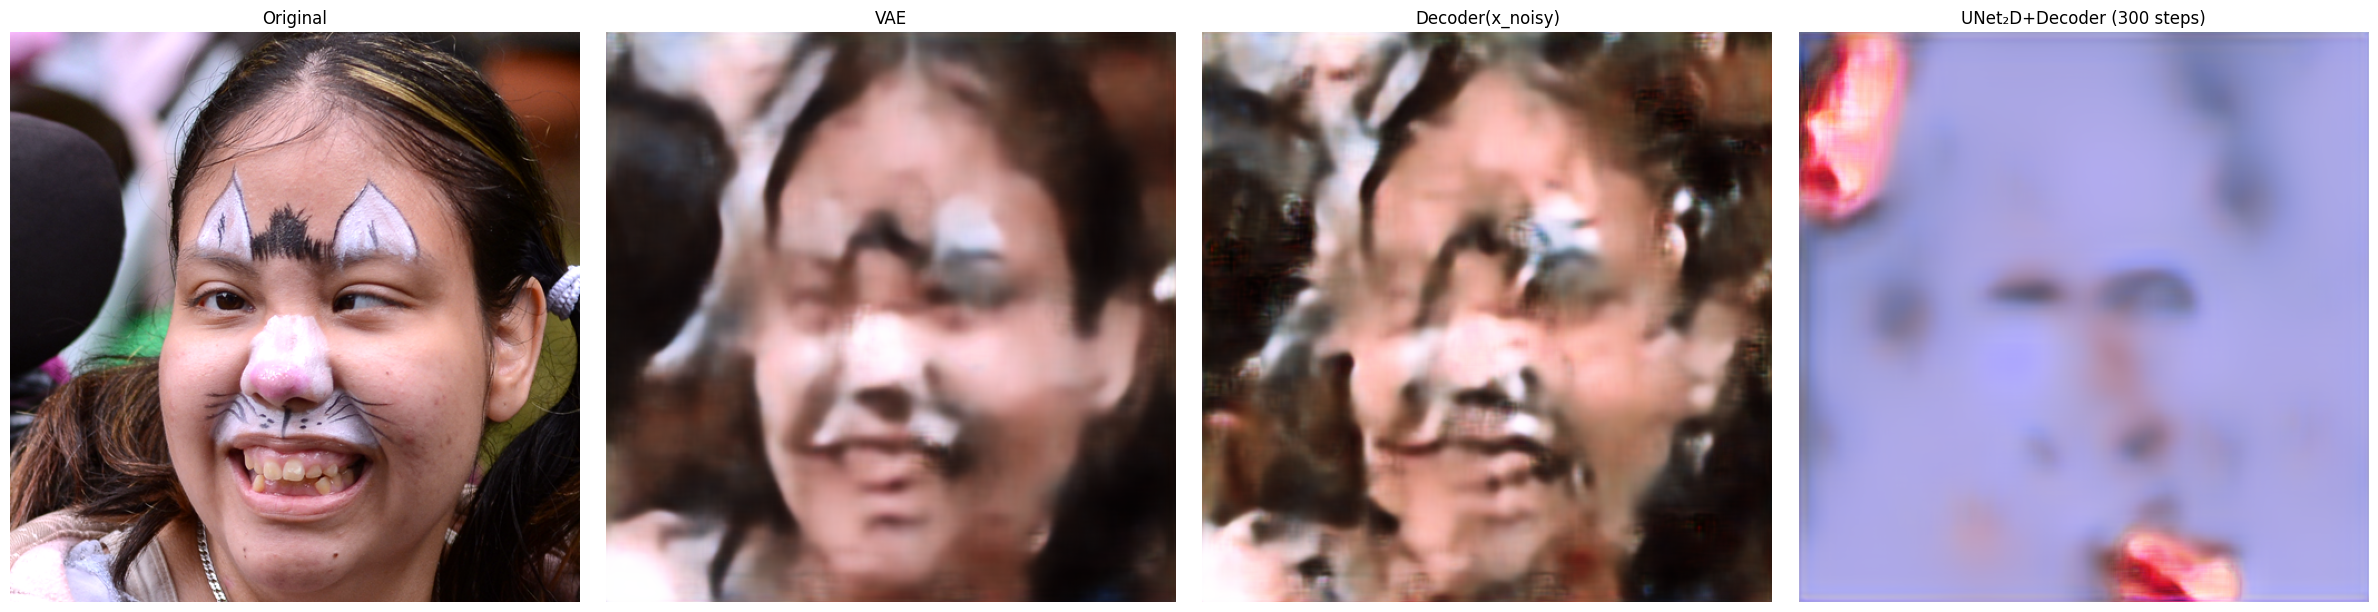

Model saved with validation loss: 0.6262



Epoch 2/10:   0%|          | 0/8000 [00:00<?, ?it/s, loss=0.5658, lr=1.94e-04]

[Epoch 1 - Batch 0] latent mean: -0.0003705297422129661
[Epoch 1 - Batch 0] latent std: 0.1146220788359642


Epoch 2/10:   0%|          | 2/8000 [00:00<50:01,  2.66it/s, loss=0.7238, lr=1.94e-04]  

[Epoch 1 - Batch 0] decoder output min: -0.9755070209503174
[Epoch 1 - Batch 0] decoder output max: 1.0
[Epoch 1 - Batch 0] decoder output std: 0.6276135444641113
[Epoch 1 - Batch 0] x_noisy mean: -0.00023763845092616975
[Epoch 1 - Batch 0] x_noisy std: 0.14462941884994507


Epoch 2/10:   3%|▎         | 231/8000 [00:45<25:43,  5.03it/s, loss=0.6321, lr=1.93e-04]

Bad loss at epoch 1, step 8231: nan


ValueError: Loss is not finite

In [ ]:
# Training
global_step = 0

for ep in range(cfg.epoch_diff):
    diffusion_model.train()
    epoch_losses, t_vals = [], []

    stats.clear()
    grads.clear()

    pbar = tqdm(train_loader, desc=f"Epoch {ep+1}/{cfg.epoch_diff}")
    for batch_idx, batch in enumerate(pbar):
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        imgs = imgs.to(cfg.device)

        # Freeze VAE encoder for latent extraction
        with torch.no_grad():
            _, _, lat, skips = vae.encoder(imgs)
            if batch_idx == 0:
                print(f"[Epoch {ep} - Batch {batch_idx}] latent mean:", lat.mean().item())
                print(f"[Epoch {ep} - Batch {batch_idx}] latent std:", lat.std().item())

        # Sample diffusion timestep t
        t = t_strategy_v3(ep, cfg.epoch_diff, imgs.size(0), T=scheduler.num_timesteps, device=cfg.device)
        t_vals += t.tolist()

        optimizer.zero_grad()

        # Forward with autocast (mixed precision)
        with autocast(device_type=cfg.device.type):
            loss = scheduler.loss_fn(
                diffusion_model,
                lat,
                t,
                epoch=ep,
                warmup_epochs=cfg.warmup_epochs
            )
            if not torch.isfinite(loss):
                print(f"Bad loss at epoch {ep}, step {global_step}: {loss}")
                raise ValueError("Loss is not finite")

        # Backward and optimization step with AMP + gradient clipping
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(diffusion_model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        ema_helper.update(diffusion_model)   # Update EMA model
        lr_scheduler.step()
        global_step += 1

        epoch_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

        # Optional debug: print decoder and noisy output stats
        if batch_idx % 500 == 0 or batch_idx == 0:
            with torch.no_grad():
                recon = vae.decoder(lat, skips)
                print(f"\n[Epoch {ep} - Batch {batch_idx}] decoder output min:", recon.min().item())
                print(f"[Epoch {ep} - Batch {batch_idx}] decoder output max:", recon.max().item())
                print(f"[Epoch {ep} - Batch {batch_idx}] decoder output std:", recon.std().item())

                t_sample = t[0].unsqueeze(0)
                x_noisy = scheduler.q_sample(lat, t)
                if isinstance(x_noisy, tuple):
                    x_noisy = x_noisy[0]
                print(f"[Epoch {ep} - Batch {batch_idx}] x_noisy mean:", x_noisy.mean().item())
                print(f"[Epoch {ep} - Batch {batch_idx}] x_noisy std:", x_noisy.std().item())

    # Epoch summary
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    print(f"\nEpoch {ep+1} done. Avg loss: {avg_loss:.6f}")
    print("t samples:", t_vals[:5], "...", t_vals[-5:], "\n")

    # Layer-wise output std and gradient norm report
    print("—— Layer Stats ——")
    for name, s in stats.items():
        if len(s) >= 2:
            print(f"{name:25s} — std: {s[-1]:.4f} ← {s[-2]:.4f}")
    for name, g in grads.items():
        print(f"{name:25s} — grad norm: {g[-1]:.4f}")
    print("——————————————\n")

    # Visualize denoising progress
    visualize_unet2d_output(
        vae=vae,
        vae_encoder=vae.encoder,
        diffusion_model=ema_helper.ema_model,
        vae_decoder=vae.decoder,
        dataloader=train_loader,
        scheduler=scheduler,
        device=cfg.device,
        current_epoch=ep,
        max_epochs=cfg.epoch_diff
    )

    # Early stopping check
    if early_stopper.check(avg_loss, diffusion_model):
        print("Early stopping triggered.")
        break


In [ ]:
# Generate a DDIM sample with eta=0.0 (deterministic output)
generate_and_visualize_ddim_sample(
    decoder=vae.decoder,
    diffusion_model=diffusion_model,
    scheduler=scheduler,
    device=cfg.device,
    latent_shape=(1, cfg.latent_channels * 64, 64, 64)
    eta=0.0,
    title_suffix="Deterministic"
)

# Generate a DDIM sample with eta=0.5 (stochastic output)
generate_and_visualize_ddim_sample(
    decoder=vae.decoder,
    diffusion_model=diffusion_model,
    scheduler=scheduler,
    device=cfg.device,
    latent_shape=(1, cfg.latent_channels * 64, 64, 64)
    eta=0.5,
    title_suffix="Stochastic"
)
